# Init

In [1]:
%cd ..
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from model.lib.data import get_dataset

/usr2/zihaoye/TabFT


## Frequency Analysis

In [2]:
import numpy as np
from typing import Dict, Sequence
from sklearn.decomposition import PCA
from nfft import nfft_adjoint        # pip install pynfft
from scipy.stats import linregress
import matplotlib.pyplot as plt

def adaptive_kmax(t: np.ndarray, quant: float = 0.05) -> float:
    t = np.asarray(t, float)

    dists = np.partition(np.abs(t[:, None] - t[None, :]), 1, axis=1)[:, 1]
    delta = np.quantile(dists, quant)
    return np.pi / delta


def _nudft_column(
        t: np.ndarray,
        f: np.ndarray,
        k_max: float,
        nk: int
) -> np.ndarray:
    x_scaled = -(t * k_max / nk)

    kgrid = 2 * (nk + 1)

    F_full = nfft_adjoint(x_scaled, f, kgrid)

    return F_full[:nk + 1]

def pc_line_spectrum(
        X   : np.ndarray,
        y   : np.ndarray,
        pcs : Sequence[int] = (0,),
        nk  : int = 1024,
        use_adaptive_kmax: bool = False
) -> Dict[str, Dict[str, np.ndarray]]:

    X = np.asarray(X, float)
    y = np.asarray(y, complex)
    if y.ndim == 1:
        y = y[:, None]                     # (N,1)
    N, M = y.shape

    Xc  = X - X.mean(axis=0, keepdims=True)
    pca = PCA(n_components=max(pcs)+1, svd_solver="full").fit(Xc)

    results = {}

    for idx in pcs:
        e_pc = pca.components_[idx]            # (F,)
        t    = Xc @ e_pc                       # (N,)

        t = (t - t.mean()) / t.std()

        k_max = adaptive_kmax(t) if use_adaptive_kmax else np.pi
        k_vals = np.arange(1, nk + 1) * (k_max / nk)

        # NUDFT
        Fcols = [
            _nudft_column(t, y[:, m], k_max, nk)[1:]
            for m in range(M)
        ]
        F = np.stack(Fcols, axis=0) / N               # (M, nk)

        power = np.abs(F)**2
        E     = np.cumsum(power, axis=1)
        E    /= E[:, -1][:, None]

        results[f"pc{idx+1}"] = {"k": k_vals, "F": F, "E": E}

    return results


def spectrum_analysis(X_demo, y_demo):
    spec = pc_line_spectrum(X_demo, y_demo, pcs=(0,), nk=1024)

    pc1   = spec['pc1']
    kvals = pc1['k']
    F     = pc1['F'][0]
    E     = pc1['E'][0]

    plt.figure(figsize=(11, 4))
    plt.subplot(1, 2, 1)
    plt.semilogy(kvals, np.abs(F))
    plt.xlabel(r"$k$")
    plt.ylabel(r"$|F(k)|$")
    plt.title("Magnitude spectrum")

    plt.subplot(1, 2, 2)
    plt.plot(kvals, E)
    plt.xlabel(r"$k$")
    plt.ylabel(r"$E(k)$")
    plt.ylim(0, 1)
    plt.title("Cumulative energy")
    plt.tight_layout()
    plt.show()

    zeta     = 0.4                        # High freq persentage（40% Nyquist）
    idx_cut  = int(zeta * len(kvals))
    hf_energy = 1.0 - E[idx_cut]
    print(f"HF-energy (> {zeta:.0%} Nyq) = {hf_energy:.2%}")

    frac = 0.10
    idx0 = int(frac * len(kvals))
    logk = np.log(kvals[idx0:])
    logA = np.log(np.abs(F[idx0:]) + 1e-16)
    alpha = -linregress(logk, logA).slope
    print(f"Spectral-decay exponent α ≈ {alpha:.2f}")

## Conditional Expectation

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle

def _conditional_expectation(x: np.ndarray, y_bin: np.ndarray):
    order = np.argsort(x)
    x_sorted, y_sorted = x[order], y_bin[order]
    unique_x, idx = np.unique(x_sorted, return_inverse=True)

    sum_y  = np.bincount(idx, weights=y_sorted, minlength=unique_x.size)
    cnt_y  = np.bincount(idx, minlength=unique_x.size).astype(float)
    mu     = np.divide(sum_y, cnt_y, out=np.zeros_like(sum_y), where=cnt_y > 0)
    return unique_x, mu


def _compute_optimal_T(x: np.ndarray, y: np.ndarray):
    order = np.argsort(x)
    x_sorted, y_sorted = x[order], y[order]
    delta_y = np.diff(y_sorted)
    TV = np.sum(np.abs(delta_y))
    return TV


def analyze_relative_slopes(
        X: np.ndarray,
        y: np.ndarray,
        is_regression: bool = False):
    n, d = X.shape
    class_list = np.unique(y) if not is_regression else [None]

    summary_records, all_relative_slopes = [], []
    feature_relative_slopes, cond_exp = {}, {}

    for j in range(d):
        x = X[:, j].astype(float)

        if np.allclose(x.max(), x.min()):
            summary_records.append((j, 0., 0., 0.))
            feature_relative_slopes[j] = np.array([])
            cond_exp[j] = []
            continue

        x = (x - x.min()) / (x.max() - x.min())

        feature_slopes, feature_curves = [], []

        for c in class_list:
            y_bin = (y == c).astype(float) if c is not None else y.astype(float)
            if is_regression and c is None and y_bin.ptp() > 0:
                y_bin = (y_bin - y_bin.min()) / y_bin.ptp()

            u, mu = _conditional_expectation(x, y_bin)
            if len(u) <= 1:
                feature_curves.append((c, u, mu))   # still store for completeness
                continue

            mu_c = mu - mu.mean()
            feature_curves.append((c, u, mu_c))

            T_opt = _compute_optimal_T(u, mu_c)
            if T_opt == 0:
                continue

            slopes = np.diff(mu_c) / np.diff(u)
            rel_slopes = np.abs(slopes) / T_opt
            feature_slopes.extend(rel_slopes)

        feature_slopes = np.asarray(feature_slopes)
        feature_relative_slopes[j] = feature_slopes
        all_relative_slopes.extend(feature_slopes)
        cond_exp[j] = feature_curves

        max_s, min_s, mean_s = (feature_slopes.max(),
                                feature_slopes.min(),
                                feature_slopes.mean()) if feature_slopes.size else (0., 0., 0.)
        summary_records.append((j, max_s, min_s, mean_s))

    summary_df = (pd.DataFrame(summary_records,
                               columns=['feature', 'max_relative_slope',
                                        'min_relative_slope', 'mean_relative_slope'])
                    .set_index('feature'))

    return dict(summary=summary_df,
                relative_slopes=feature_relative_slopes,
                all_relative_slopes=np.asarray(all_relative_slopes),
                cond_exp=cond_exp)


def plot_relative_slope_distribution(results: dict,
                                     feature_idx: int = None,
                                     bins: int = 50,
                                     figsize: tuple = (12, 4),
                                     class_label=None,
                                     show_conditional=True):
    import matplotlib.pyplot as plt


    if feature_idx is not None:
        slopes = results['relative_slopes'][feature_idx]
        if slopes.size == 0:
            print(f"Feature {feature_idx} has no relative slopes to plot.")
            return

        nrows = 2 if show_conditional else 1
        fig, axes = plt.subplots(nrows, 1, figsize=figsize)
        if isinstance(axes, np.ndarray):
            axes = axes.ravel().tolist()
        else:
            axes = [axes]

        ax_hist = axes[0]
        ax_hist.hist(slopes, bins=bins, density=True, alpha=0.7,
                     edgecolor='black', linewidth=0.5)
        ax_hist.axvline(slopes.max(),  c='red',   ls='--', label=f'Max {slopes.max():.3f}')
        ax_hist.axvline(slopes.min(),  c='blue',  ls='--', label=f'Min {slopes.min():.3f}')
        ax_hist.axvline(slopes.mean(), c='green', ls='--', label=f'Mean {slopes.mean():.3f}')
        ax_hist.set_xlabel('Relative slope')
        ax_hist.set_ylabel('Density')
        ax_hist.set_title(f'Relative-slope distribution | feature {feature_idx}')
        ax_hist.grid(alpha=0.3)
        ax_hist.legend()

        if show_conditional:
            ax_curve = axes[1]
            curves = results['cond_exp'].get(feature_idx, [])
            to_plot = curves if class_label is None \
                           else [c for c in curves if c[0] == class_label]

            if not to_plot:
                ax_curve.set_title('No curve available')
            else:
                for c, u, mu_c in to_plot:
                    lbl = f'class {c}' if c is not None else 'regression'
                    ax_curve.plot(u, mu_c, lw=2, label=lbl)

            ax_curve.set_xlabel('u (feature value)')
            ax_curve.set_ylabel(r'$\mu_c(u)$  (mean-centred)')
            ax_curve.set_title('Conditional expectation')
            ax_curve.grid(alpha=0.3)
            ax_curve.legend()

        plt.tight_layout()
        return fig


    all_slopes = results['all_relative_slopes']
    if all_slopes.size == 0:
        print("No relative slopes to plot.")
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    ax1.hist(all_slopes, bins=bins, density=True, alpha=0.7,
             edgecolor='black', linewidth=0.5)
    ax1.axvline(all_slopes.max(), color='red',   ls='--', label=f'Max {all_slopes.max():.3f}')
    ax1.axvline(all_slopes.min(), color='blue',  ls='--', label=f'Min {all_slopes.min():.3f}')
    ax1.axvline(all_slopes.mean(),color='green', ls='--', label=f'Mean {all_slopes.mean():.3f}')
    ax1.set_xlabel('Relative slope')
    ax1.set_ylabel('Density')
    ax1.set_title('Overall relative-slope distribution')
    ax1.grid(alpha=0.3)
    ax1.legend()

    feature_data = [v for v in results['relative_slopes'].values() if v.size]
    labels = [f'F{j}' for j, v in results['relative_slopes'].items() if v.size]
    if feature_data:
        ax2.boxplot(feature_data, labels=labels, showfliers=False)
        ax2.set_xlabel('Feature')
        ax2.set_ylabel('Relative slope')
        ax2.set_title('Per-feature distribution')
        ax2.grid(alpha=0.3)
        plt.setp(ax2.get_xticklabels(), rotation=45)

    plt.tight_layout()
    return fig


def get_relative_slope_stats(results: dict, feature_idx: int = None):
    if feature_idx is not None:
        slopes = results['relative_slopes'][feature_idx]
        if len(slopes) == 0:
            return {'count': 0, 'mean': 0, 'std': 0, 'min': 0, 'max': 0}
        
        return {
            'count': len(slopes),
            'mean': slopes.mean(),
            'std': slopes.std(),
            'min': slopes.min(),
            'max': slopes.max(),
            'median': np.median(slopes),
            'q25': np.percentile(slopes, 25),
            'q75': np.percentile(slopes, 75)
        }
    else:
        stats_list = []
        for feature_idx, slopes in results['relative_slopes'].items():
            if len(slopes) == 0:
                stats_list.append([feature_idx, 0, 0, 0, 0, 0, 0, 0, 0])
            else:
                stats_list.append([
                    feature_idx,
                    len(slopes),
                    slopes.mean(),
                    slopes.std(),
                    slopes.min(),
                    slopes.max(),
                    np.median(slopes),
                    np.percentile(slopes, 25),
                    np.percentile(slopes, 75)
                ])
        
        return pd.DataFrame(stats_list, 
                           columns=['feature', 'count', 'mean', 'std', 'min', 'max', 'median', 'q25', 'q75'])

## Transform Analysis

In [4]:
def transform_analysis(transform_list, N_data, C_data, y_data, is_regression=False):
    import numpy as np, matplotlib.pyplot as plt, math
    from transform.transform_pipeline import DataTransformPipeline
    from types import SimpleNamespace

    args = SimpleNamespace(seed=0)
    pipeline = DataTransformPipeline(transform_list, args, is_regression=is_regression)

    N_trans, C_trans, y_trans = pipeline.fit_transform(N_data=N_data.copy(), C_data=C_data, y_data=y_data)

    N_trans_train = N_trans['train']  # (n_samples, n_features)

    import math, numpy as np, matplotlib.pyplot as plt

    col_num = min(N_trans_train.shape[1], 30)
    cols    = min(max(col_num, 2), 5)
    rows    = math.ceil(col_num / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*2.5), squeeze=False)
    axes      = axes.reshape(rows, cols)

    for i in range(col_num):
        row, col = divmod(i, cols)
        axes[row, col].hist(N_trans_train[:, i], bins=100)
        axes[row, col].set_title(f'Column {i+1}')
        axes[row, col].set_xlabel('Value')
        axes[row, col].set_ylabel('Frequency')

    for j in range(col_num, rows*cols):
        axes.flat[j].set_visible(False)

    plt.tight_layout()
    plt.show()
    
    if N_trans is not None:
        data = N_trans['train']
    else:
        data = C_trans['train']

    spectrum_analysis(data, y_trans['train'])

    import pandas as pd

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    results = analyze_relative_slopes(data, y_trans['train'], is_regression=is_regression)
    print("Relative Slopes Analysis:")
    print(results['summary'])
    plot_relative_slope_distribution(results)
    stats = get_relative_slope_stats(results)
    print("Relative Slopes Statistics:")
    print(stats)

    return N_trans, C_trans, y_trans, results

# Dataset

In [17]:
# Load dataset
# dataset_name = 'Contaminant-detection-in-packaged-cocoa-hazelnut-spread-jars-using-Microwaves-Sensing-and-Machine-Learning-11.0GHz(Urbinati)'
# dataset_name = 'E-CommereShippingData'
# dataset_name = 'estimation_of_obesity_levels'
dataset_name = 'ASP-POTASSCO-classification'
# dataset_name = 'Ailerons'
# dataset_name = 'Bias_correction_r_2'
# dataset_name = 'electricity'
# dataset_name = 'Diamonds'
# dataset_name = 'Ailerons_DPGMM'
# dataset_name = 'IEEE80211aa-GATS'
# dataset_name = 'Intersectional-Bias-Assessment'
# dataset_name = 'Mobile_Price_Classification'
# dataset_name = 'Waterstress'
# dataset_name = 'FOREX_audjpy-day-High'
# dataset_name = 'internet_firewall'
# dataset_name = 'BNG(tic-tac-toe)'
# dataset_name = 'Fitness_Club_c'

dataset_path = 'data'
train_val_data,test_data,info = get_dataset(dataset_name,dataset_path)
is_regression = (info['task_type'] == 'regression')
N_data = train_val_data[0] if train_val_data[0] else None
C_data = train_val_data[1] if train_val_data[1] else None
y_data = train_val_data[2] if train_val_data[2] else None
    

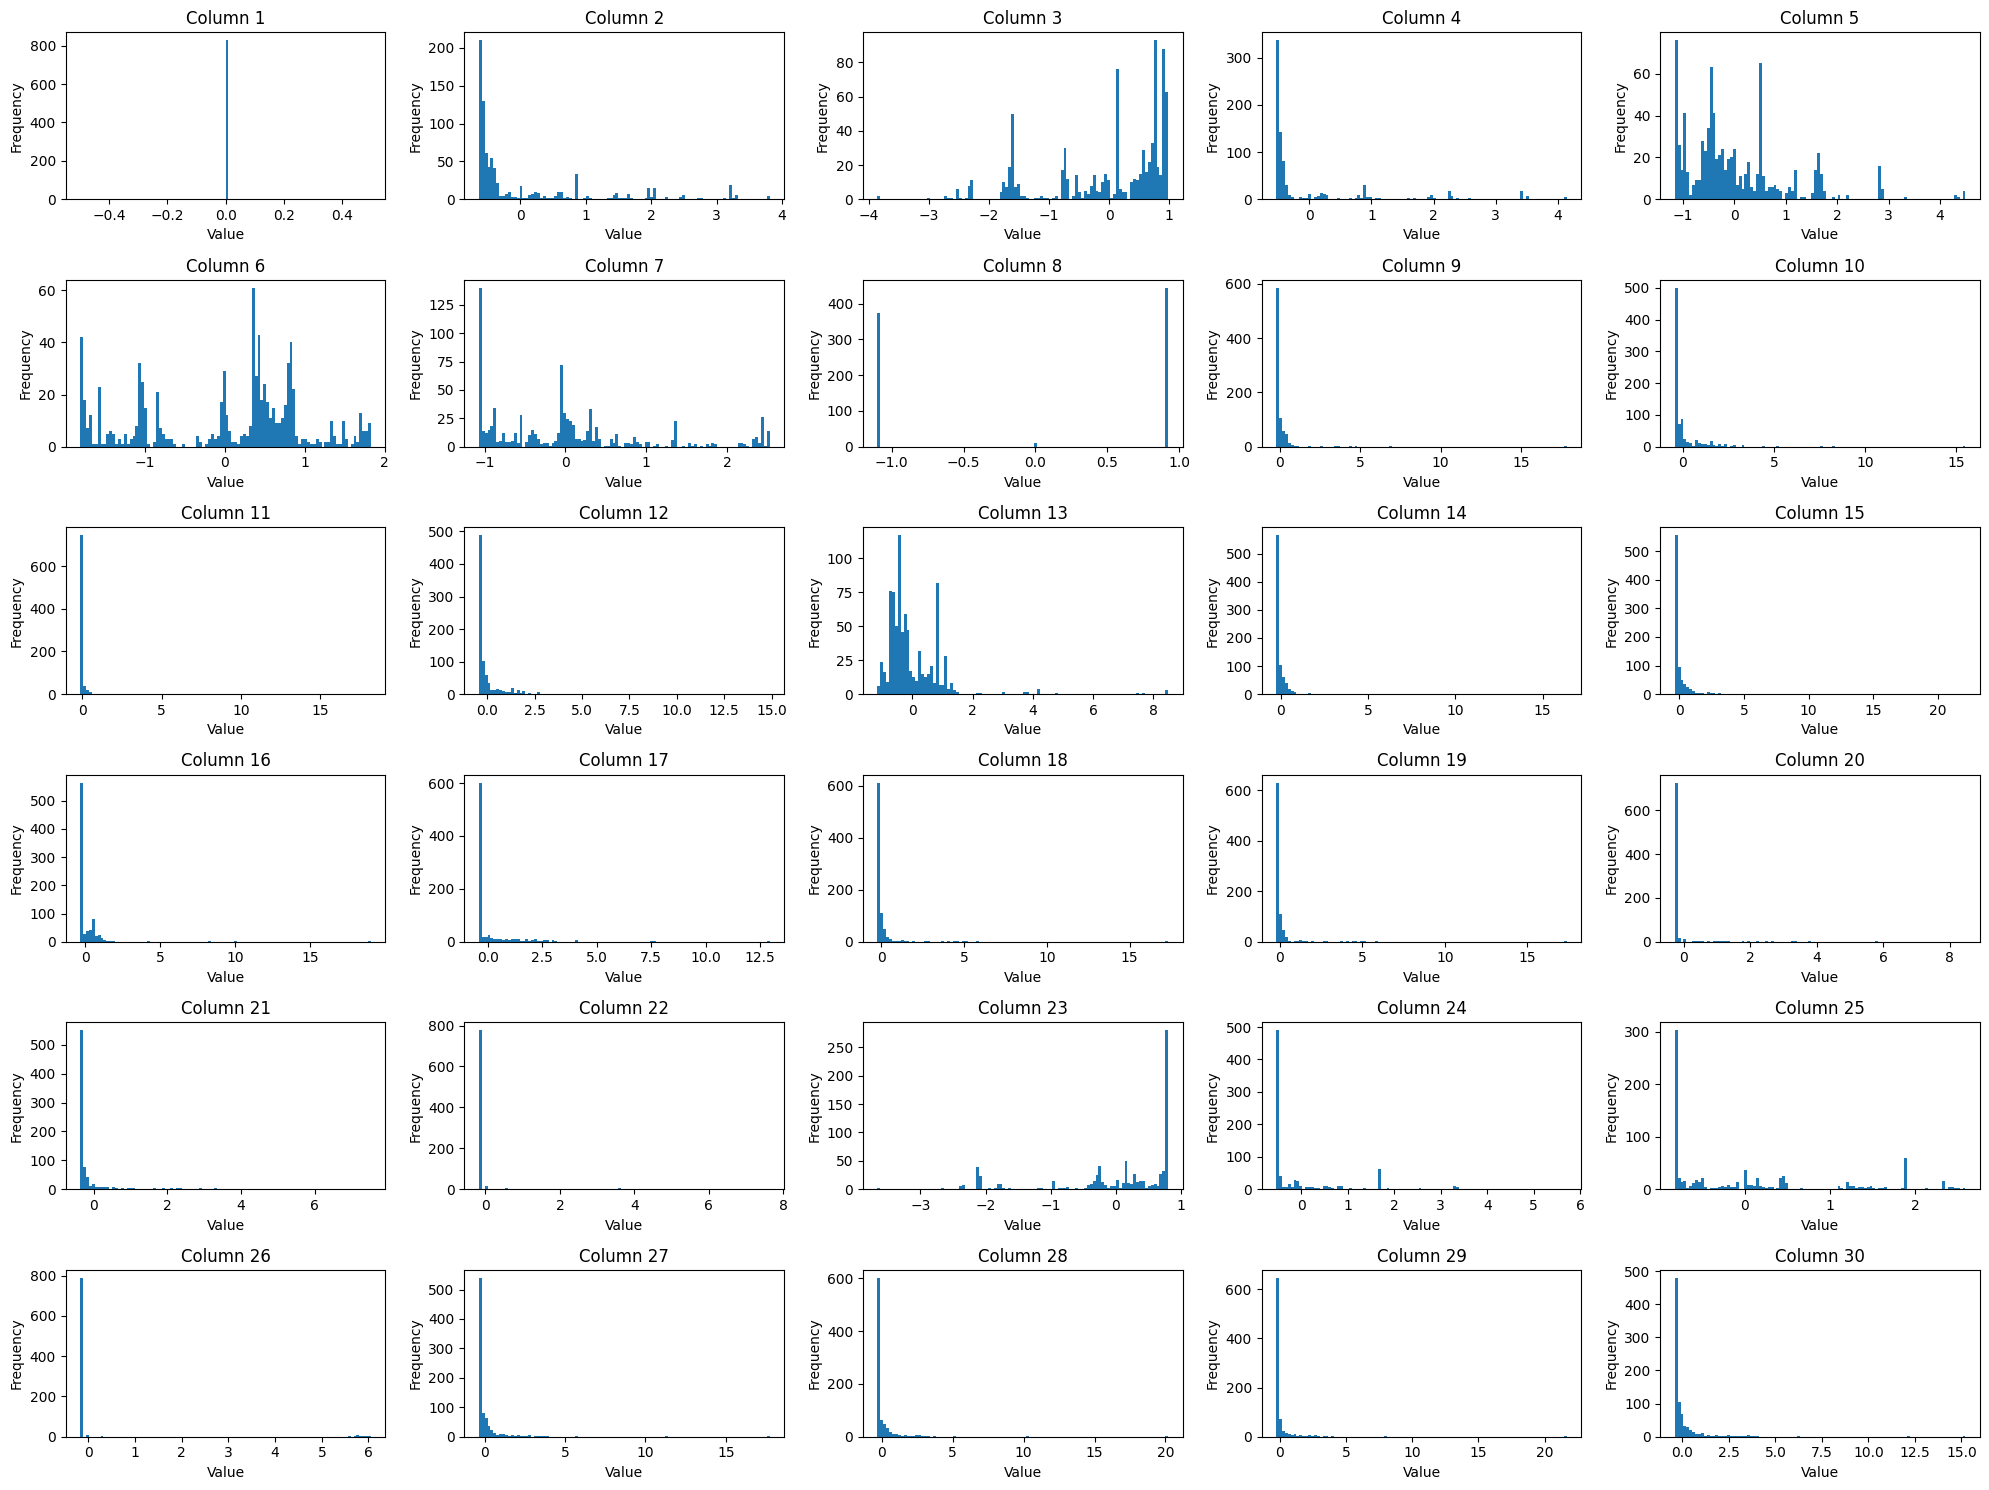

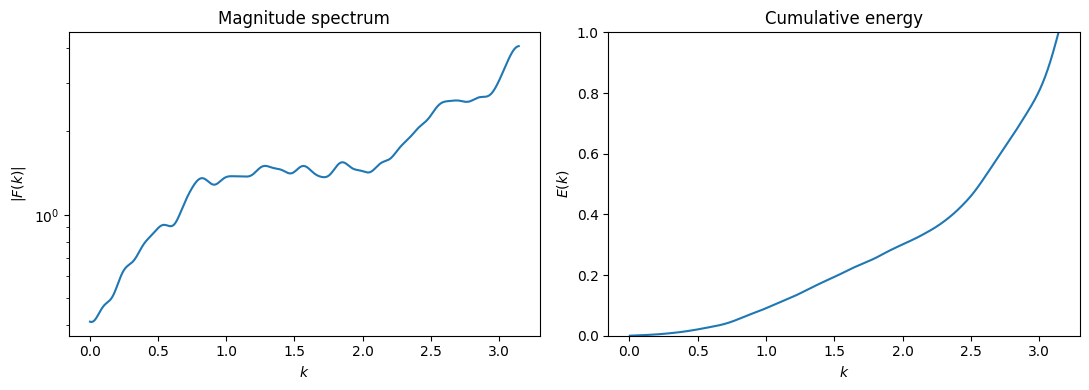

HF-energy (> 40% Nyq) = 85.85%
Spectral-decay exponent α ≈ -0.58
Relative Slopes Analysis:
         max_relative_slope  min_relative_slope  mean_relative_slope
feature                                                             
0              0.000000e+00            0.000000             0.000000
1              4.054536e+02            0.000000             9.483633
2              5.214261e+02            0.000000             7.648774
3              6.070198e+02            0.000000            12.254487
4              4.200275e+02            0.000000             6.080377
5              3.524632e+02            0.000000             4.864232
6              5.166525e+02            0.000000             6.050342
7              1.688017e+00            0.417635             0.997317
8              3.346837e+05            0.000000          1037.312290
9              7.143223e+04            0.000000           278.375612
10             2.981163e+05            0.000000          2086.268806
11          

/tmp/ipykernel_2276772/1717818865.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(feature_data, labels=labels, showfliers=False)


Relative Slopes Statistics:
     feature  count         mean           std       min           max  \
0          0      0     0.000000      0.000000  0.000000  0.000000e+00   
1          1   5764     9.483633     29.569825  0.000000  4.054536e+02   
2          2   5764     7.648774     29.209624  0.000000  5.214261e+02   
3          3   4466    12.254487     35.878266  0.000000  6.070198e+02   
4          4   6842     6.080377     21.959472  0.000000  4.200275e+02   
5          5   6864     4.864232     19.054570  0.000000  3.524632e+02   
6          6   5544     6.050342     26.063392  0.000000  5.166525e+02   
7          7     22     0.997317      0.309257  0.417635  1.688017e+00   
8          8   8239  1037.312290   7282.798317  0.000000  3.346837e+05   
9          9   7777   278.375612   1974.102082  0.000000  7.143223e+04   
10        10   6743  2086.268806  12268.596388  0.000000  2.981163e+05   
11        11   8459   611.006052   5319.494133  0.000000  2.694209e+05   
12        

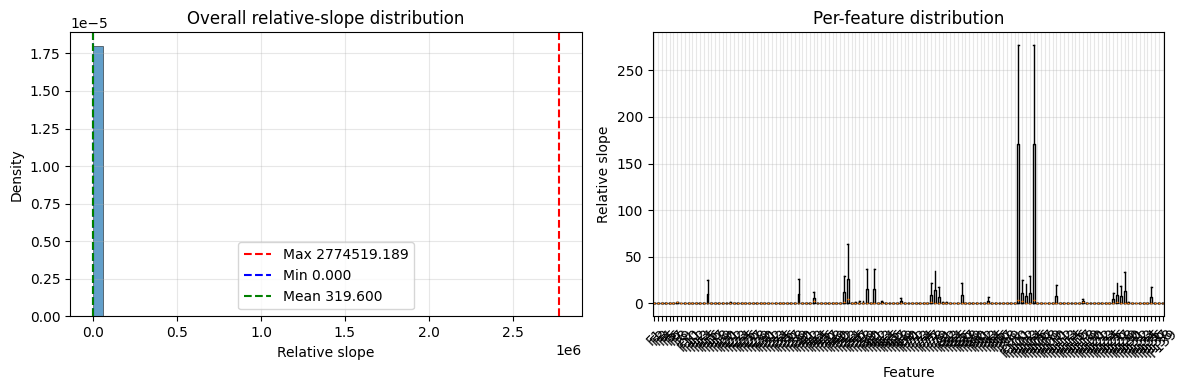

In [18]:
transform_list = [
    {
        'nan': {}
    },
    {
        'label': {}
    },
    {
        'cat_indice': {}
    },
    {
        'norm':
            {
                'policy': 'standard'
            }
    }
]

N_data, C_data, y_data, ori_results = transform_analysis(transform_list, N_data, C_data, y_data, is_regression)

In [ ]:
plot_relative_slope_distribution(ori_results, feature_idx=1, figsize=(16, 8))
plt.show()

# Transform

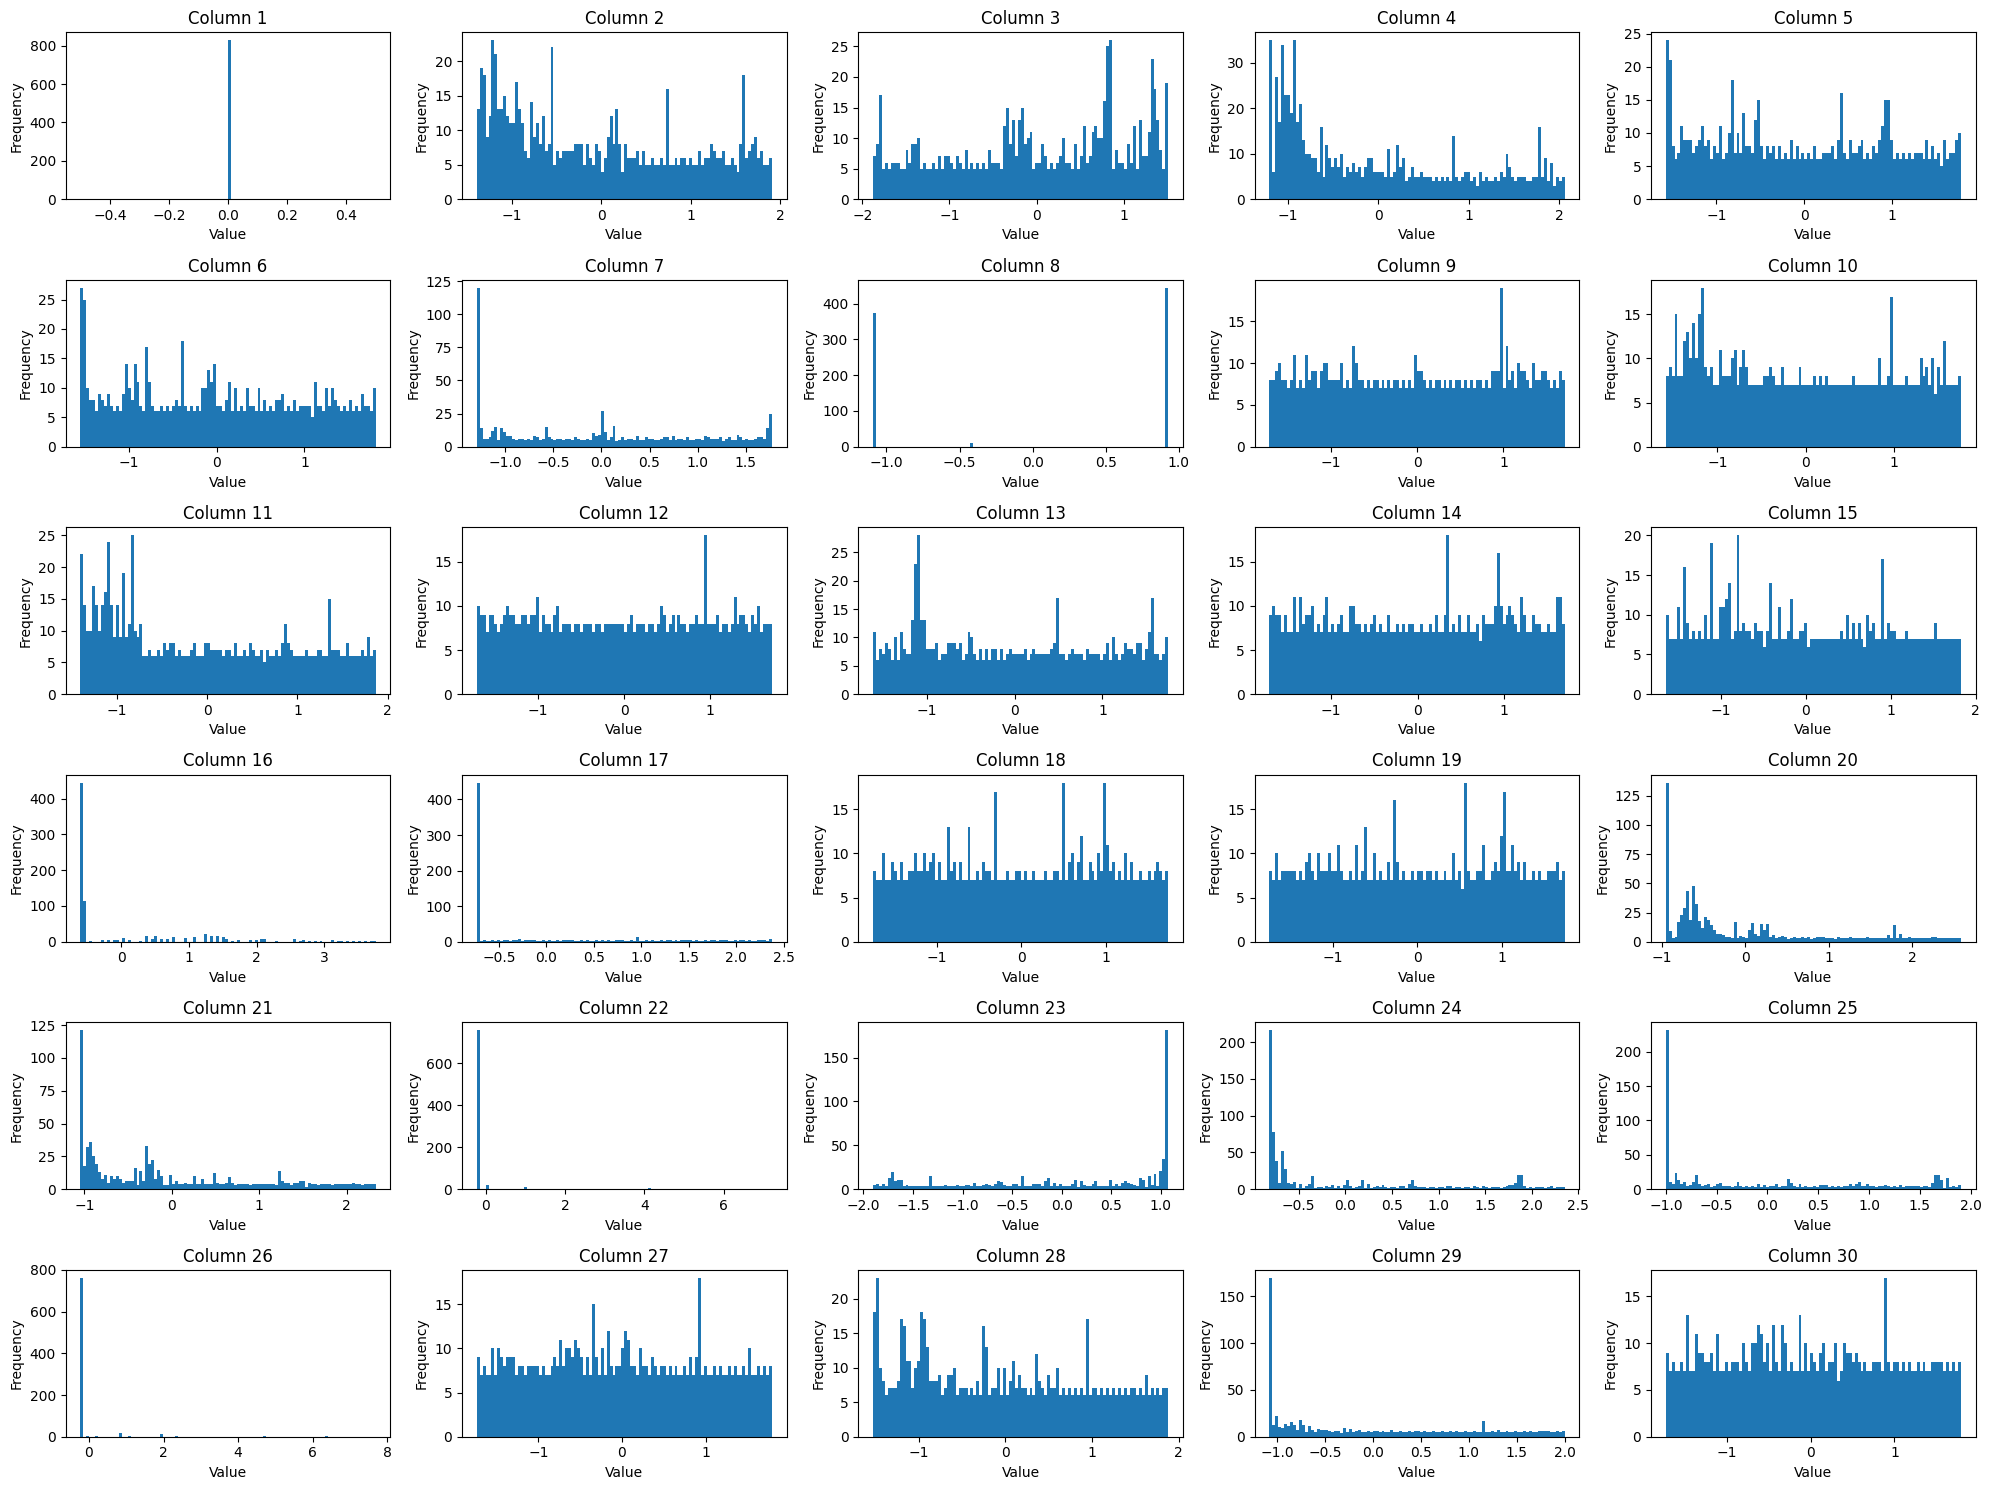

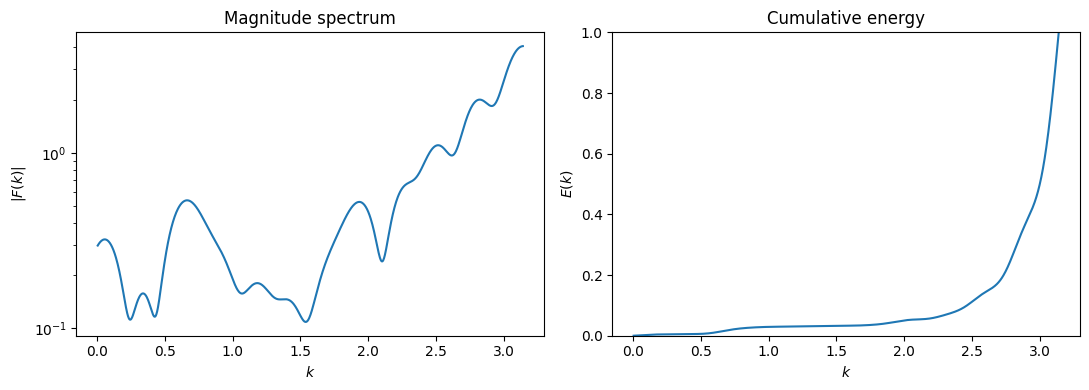

HF-energy (> 40% Nyq) = 96.87%
Spectral-decay exponent α ≈ -1.06
Relative Slopes Analysis:
         max_relative_slope  min_relative_slope  mean_relative_slope
feature                                                             
0                  0.000000            0.000000             0.000000
1                 23.503215            0.000000             1.011857
2                 28.435599            0.000000             1.023355
3                 30.637383            0.000000             1.048555
4                 28.039632            0.000000             1.025773
5                 35.520581            0.000000             1.018510
6                 27.705350            0.000000             1.029576
7                  2.427989            0.286006             1.169078
8                 32.668928            0.000000             1.004925
9                 30.067157            0.000000             1.003639
10                26.932556            0.000000             1.007045
11          

/tmp/ipykernel_2276772/1717818865.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(feature_data, labels=labels, showfliers=False)


Relative Slopes Statistics:
     feature  count      mean       std       min         max    median  \
0          0      0  0.000000  0.000000  0.000000    0.000000  0.000000   
1          1   5764  1.011857  2.614178  0.000000   23.503215  0.000000   
2          2   5764  1.023355  2.826859  0.000000   28.435599  0.000000   
3          3   4466  1.048555  2.693674  0.000000   30.637383  0.000000   
4          4   6842  1.025773  2.863709  0.000000   28.039632  0.000000   
5          5   6864  1.018510  2.991183  0.000000   35.520581  0.000000   
6          6   5544  1.029576  2.992855  0.000000   27.705350  0.000000   
7          7     22  1.169078  0.622458  0.286006    2.427989  1.018361   
8          8   8239  1.004925  2.888102  0.000000   32.668928  0.000000   
9          9   7777  1.003639  2.791486  0.000000   30.067157  0.000000   
10        10   6743  1.007045  2.832228  0.000000   26.932556  0.000000   
11        11   8459  1.001473  2.854128  0.000000   29.529462  0.000000 

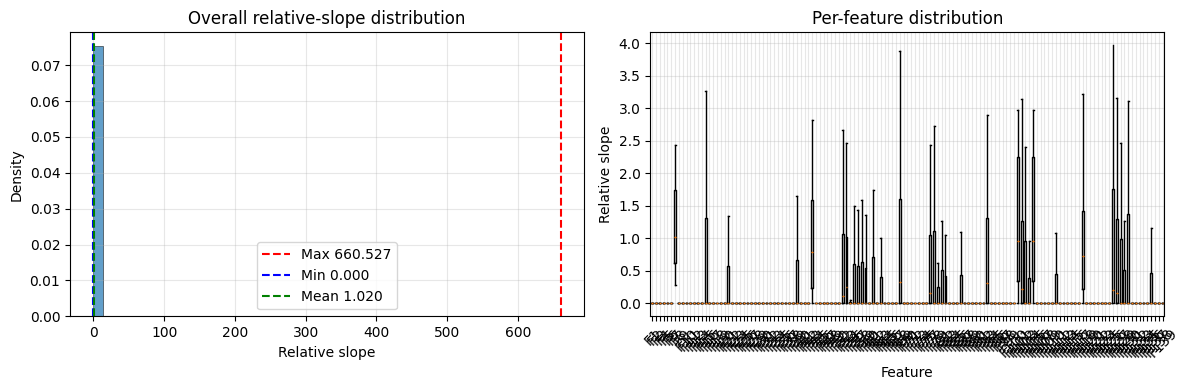

In [19]:
transform_list = [
    {
        'uniple':
            {
                'n_bins': 1000000
            }
    },
    {
        'norm':
            {
                'policy': 'standard'
            }
    }
]
N_trans, C_trans, y_trans, trans_results = transform_analysis(transform_list, N_data, C_data, y_data, is_regression)

In [ ]:
plot_relative_slope_distribution(trans_results, feature_idx=1, figsize=(16, 8))
plt.show()

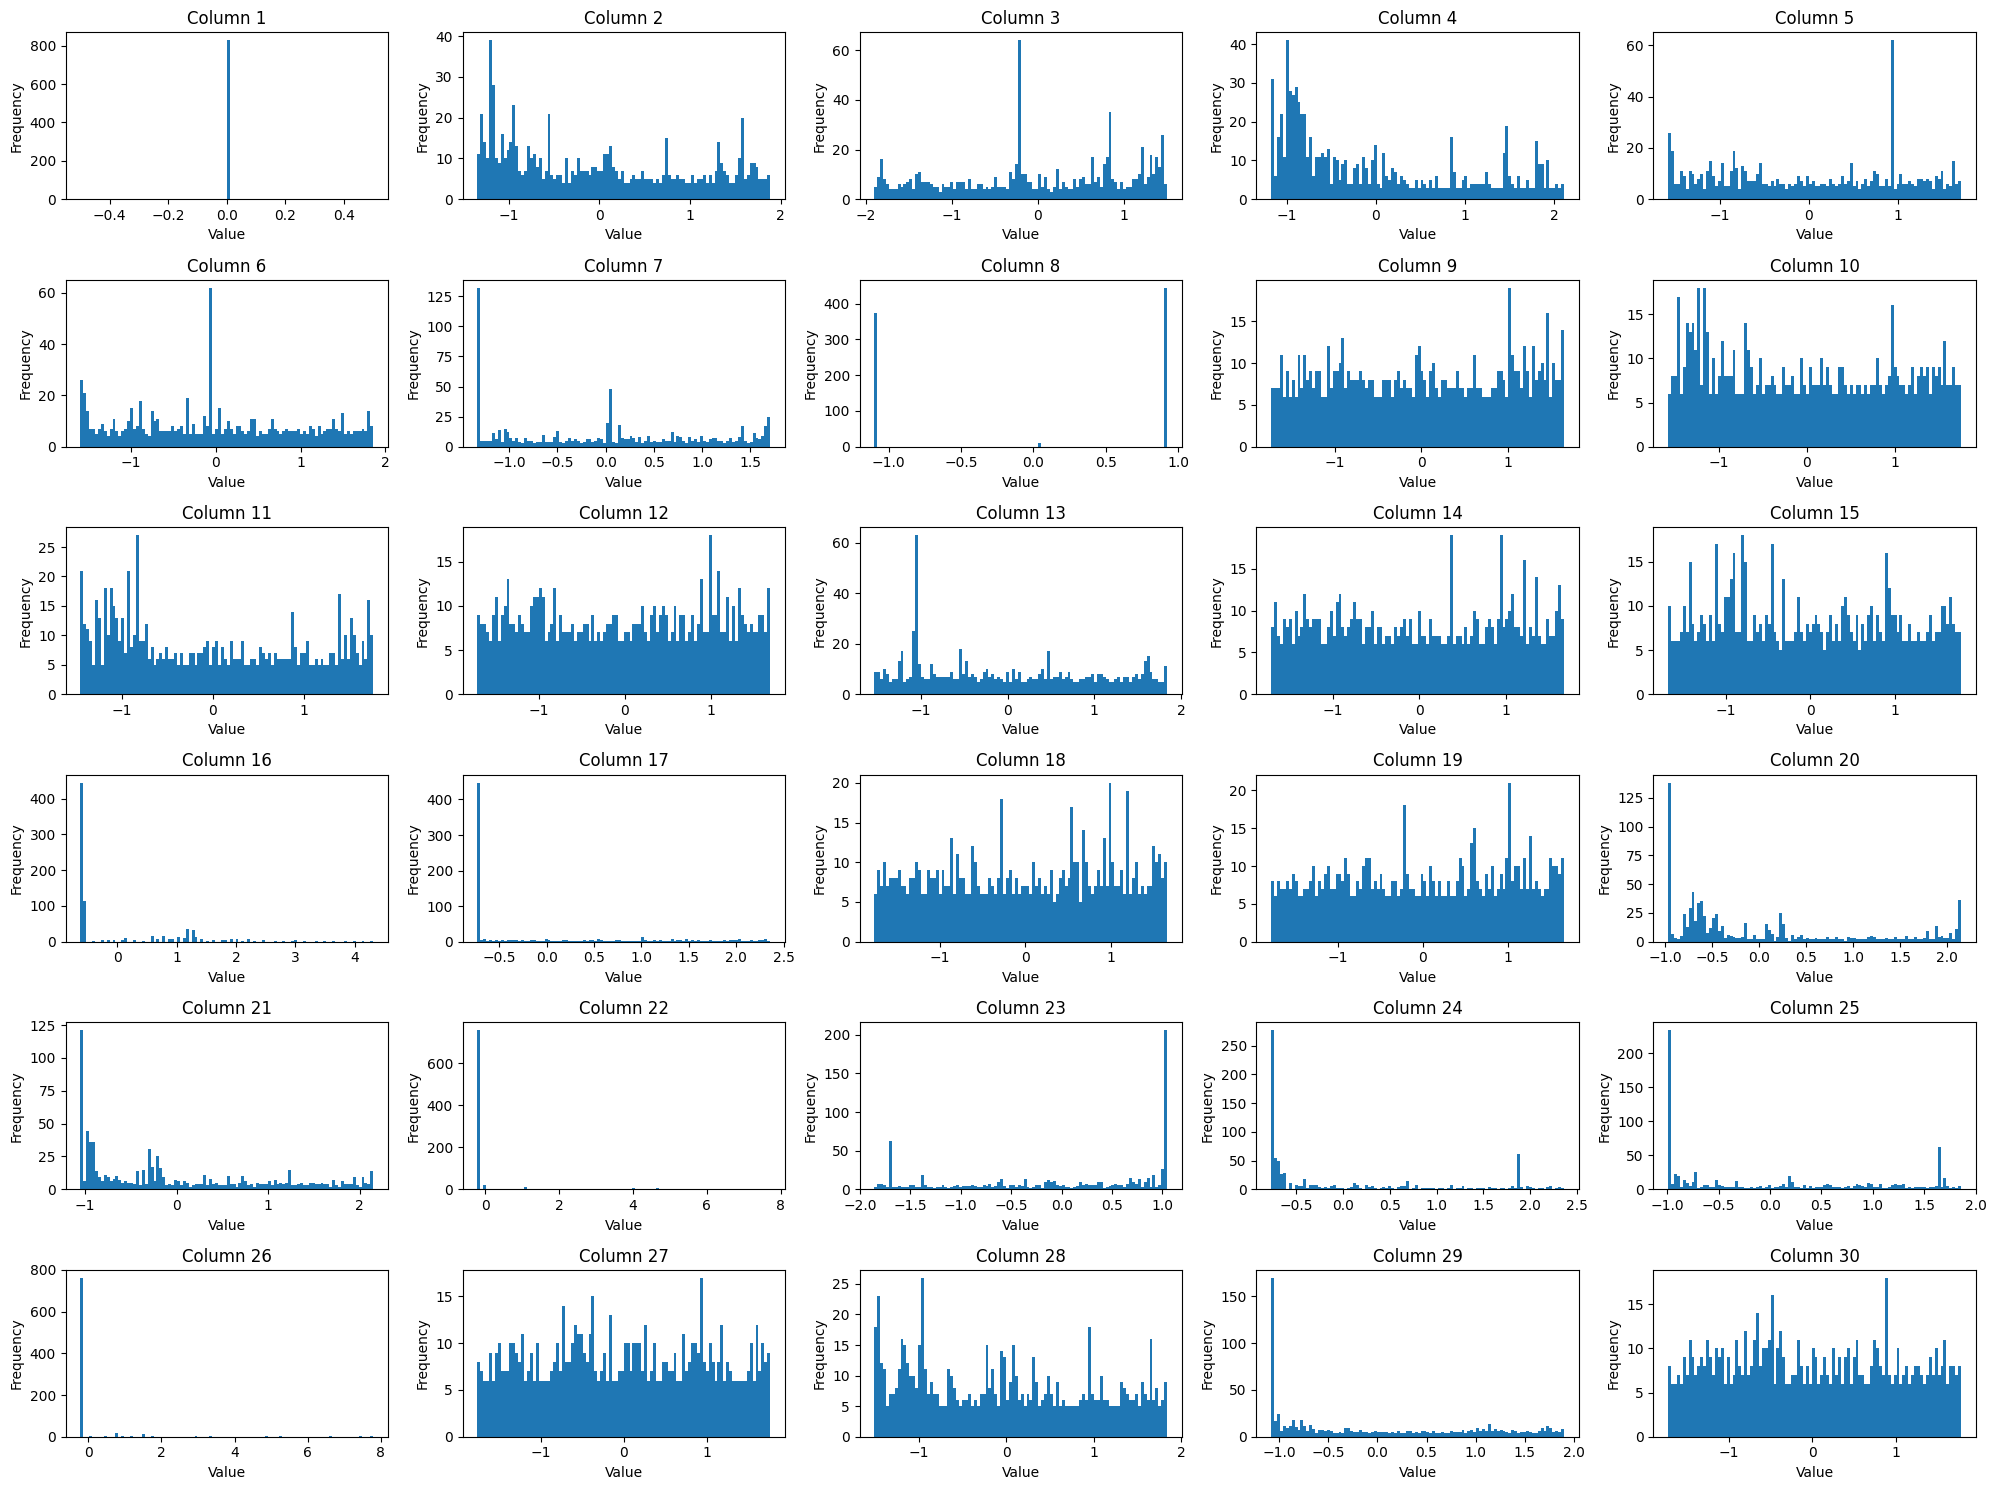

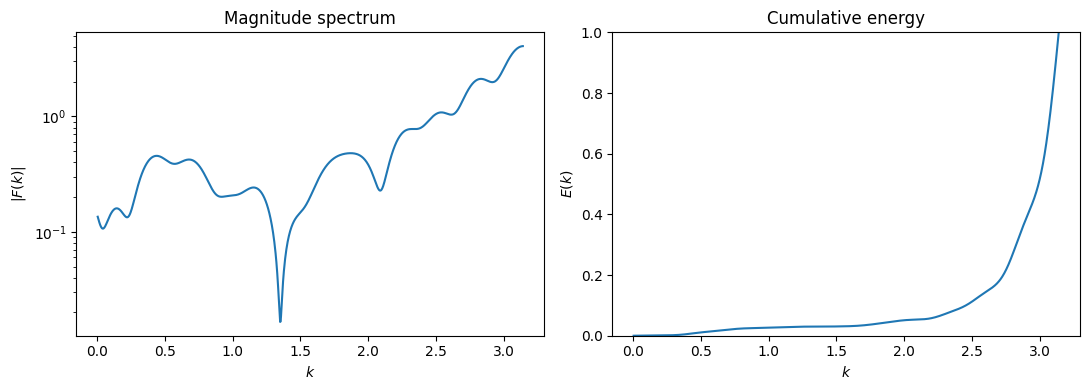

HF-energy (> 40% Nyq) = 97.01%
Spectral-decay exponent α ≈ -0.89
Relative Slopes Analysis:
         max_relative_slope  min_relative_slope  mean_relative_slope
feature                                                             
0                  0.000000             0.00000             0.000000
1                 18.195772             0.00000             0.942716
2                 20.491933             0.00000             0.944548
3                 21.815386             0.00000             0.947704
4                 20.406104             0.00000             0.948082
5                 25.293465             0.00000             0.936993
6                 19.537140             0.00000             0.953286
7                  1.768634             0.40644             1.001435
8                 26.276070             0.00000             0.923125
9                 25.315123             0.00000             0.951216
10                21.507384             0.00000             0.955984
11          

/tmp/ipykernel_2276772/1717818865.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(feature_data, labels=labels, showfliers=False)


Relative Slopes Statistics:
     feature  count      mean       std      min         max    median  \
0          0      0  0.000000  0.000000  0.00000    0.000000  0.000000   
1          1   5302  0.942716  2.209157  0.00000   18.195772  0.000000   
2          2   5016  0.944548  2.319621  0.00000   20.491933  0.000000   
3          3   4158  0.947704  2.149712  0.00000   21.815386  0.000000   
4          4   5797  0.948082  2.331373  0.00000   20.406104  0.000000   
5          5   5720  0.936993  2.384851  0.00000   25.293465  0.000000   
6          6   4741  0.953286  2.394765  0.00000   19.537140  0.000000   
7          7     22  1.001435  0.312096  0.40644    1.768634  0.995775   
8          8   7359  0.923125  2.461689  0.00000   26.276070  0.000000   
9          9   7095  0.951216  2.482243  0.00000   25.315123  0.000000   
10        10   5962  0.955984  2.460275  0.00000   21.507384  0.000000   
11        11   7403  0.934455  2.448444  0.00000   23.723485  0.000000   
12        

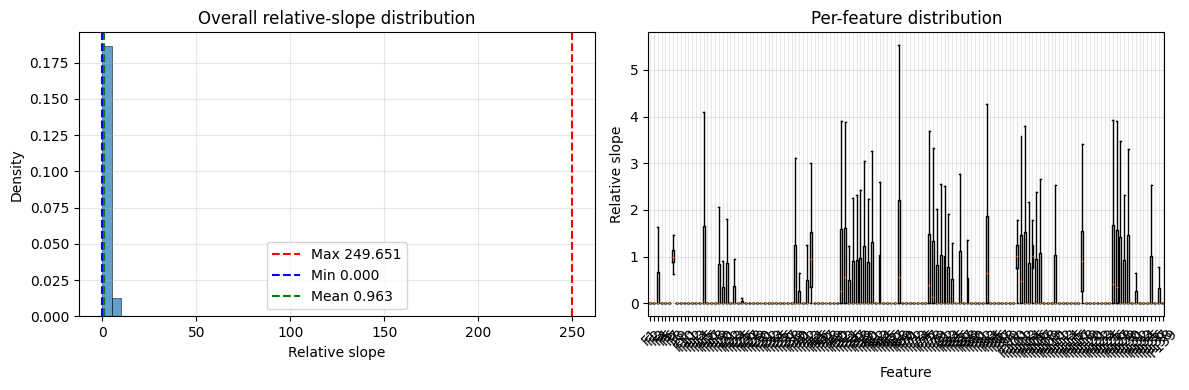

In [20]:
transform_list = [
    {
        'stretch_opt': 
            {
                'lambda_': 1.0
            }
    },
    {
        'norm':
            {
                'policy': 'standard'
            }
    }
]
N_trans, C_trans, y_trans, trans_results = transform_analysis(transform_list, N_data, C_data, y_data, is_regression)

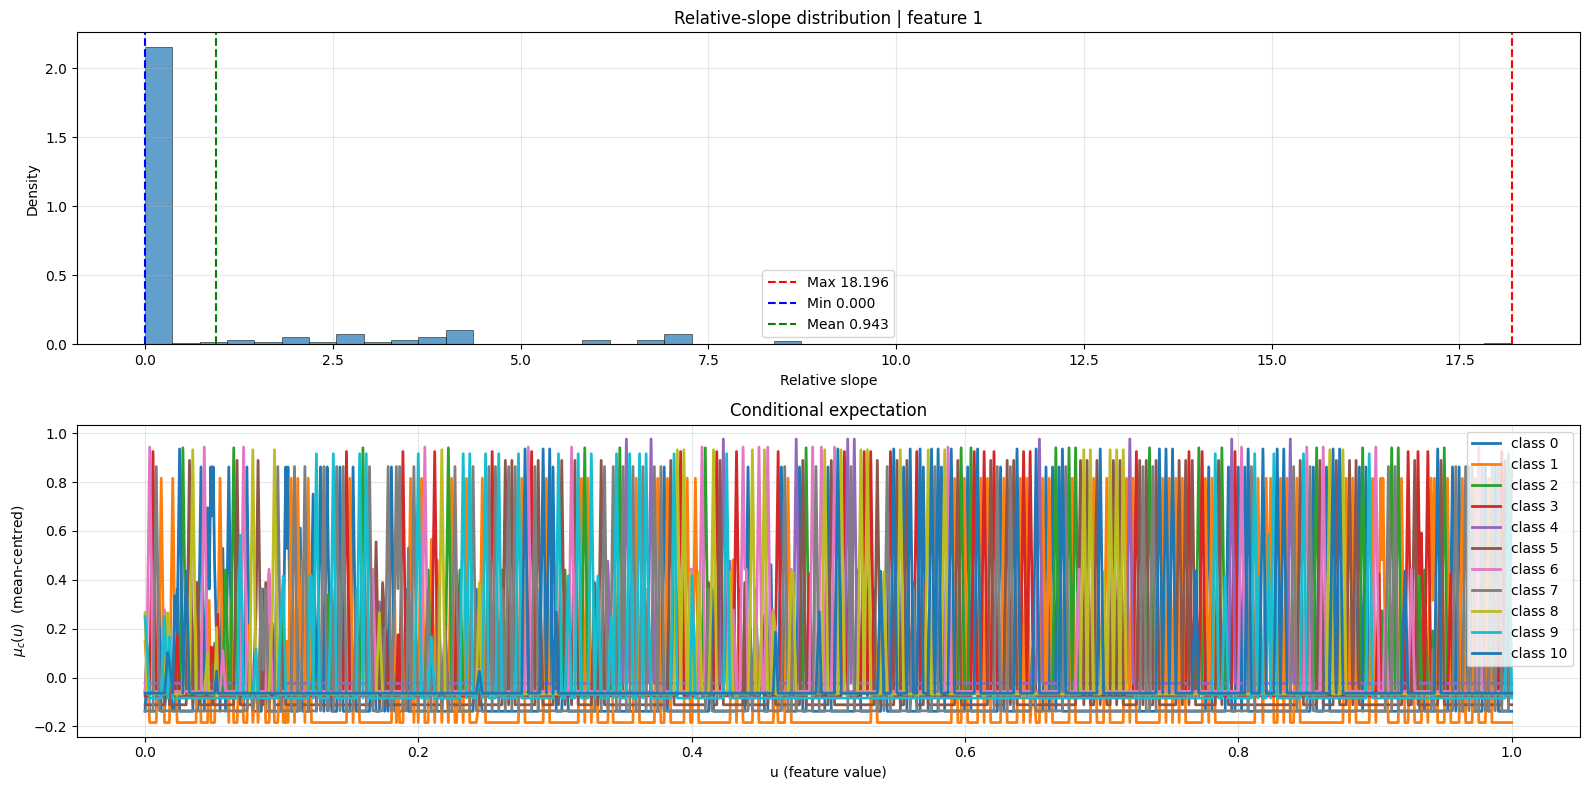

In [21]:
plot_relative_slope_distribution(trans_results, feature_idx=1, figsize=(16, 8))
plt.show()

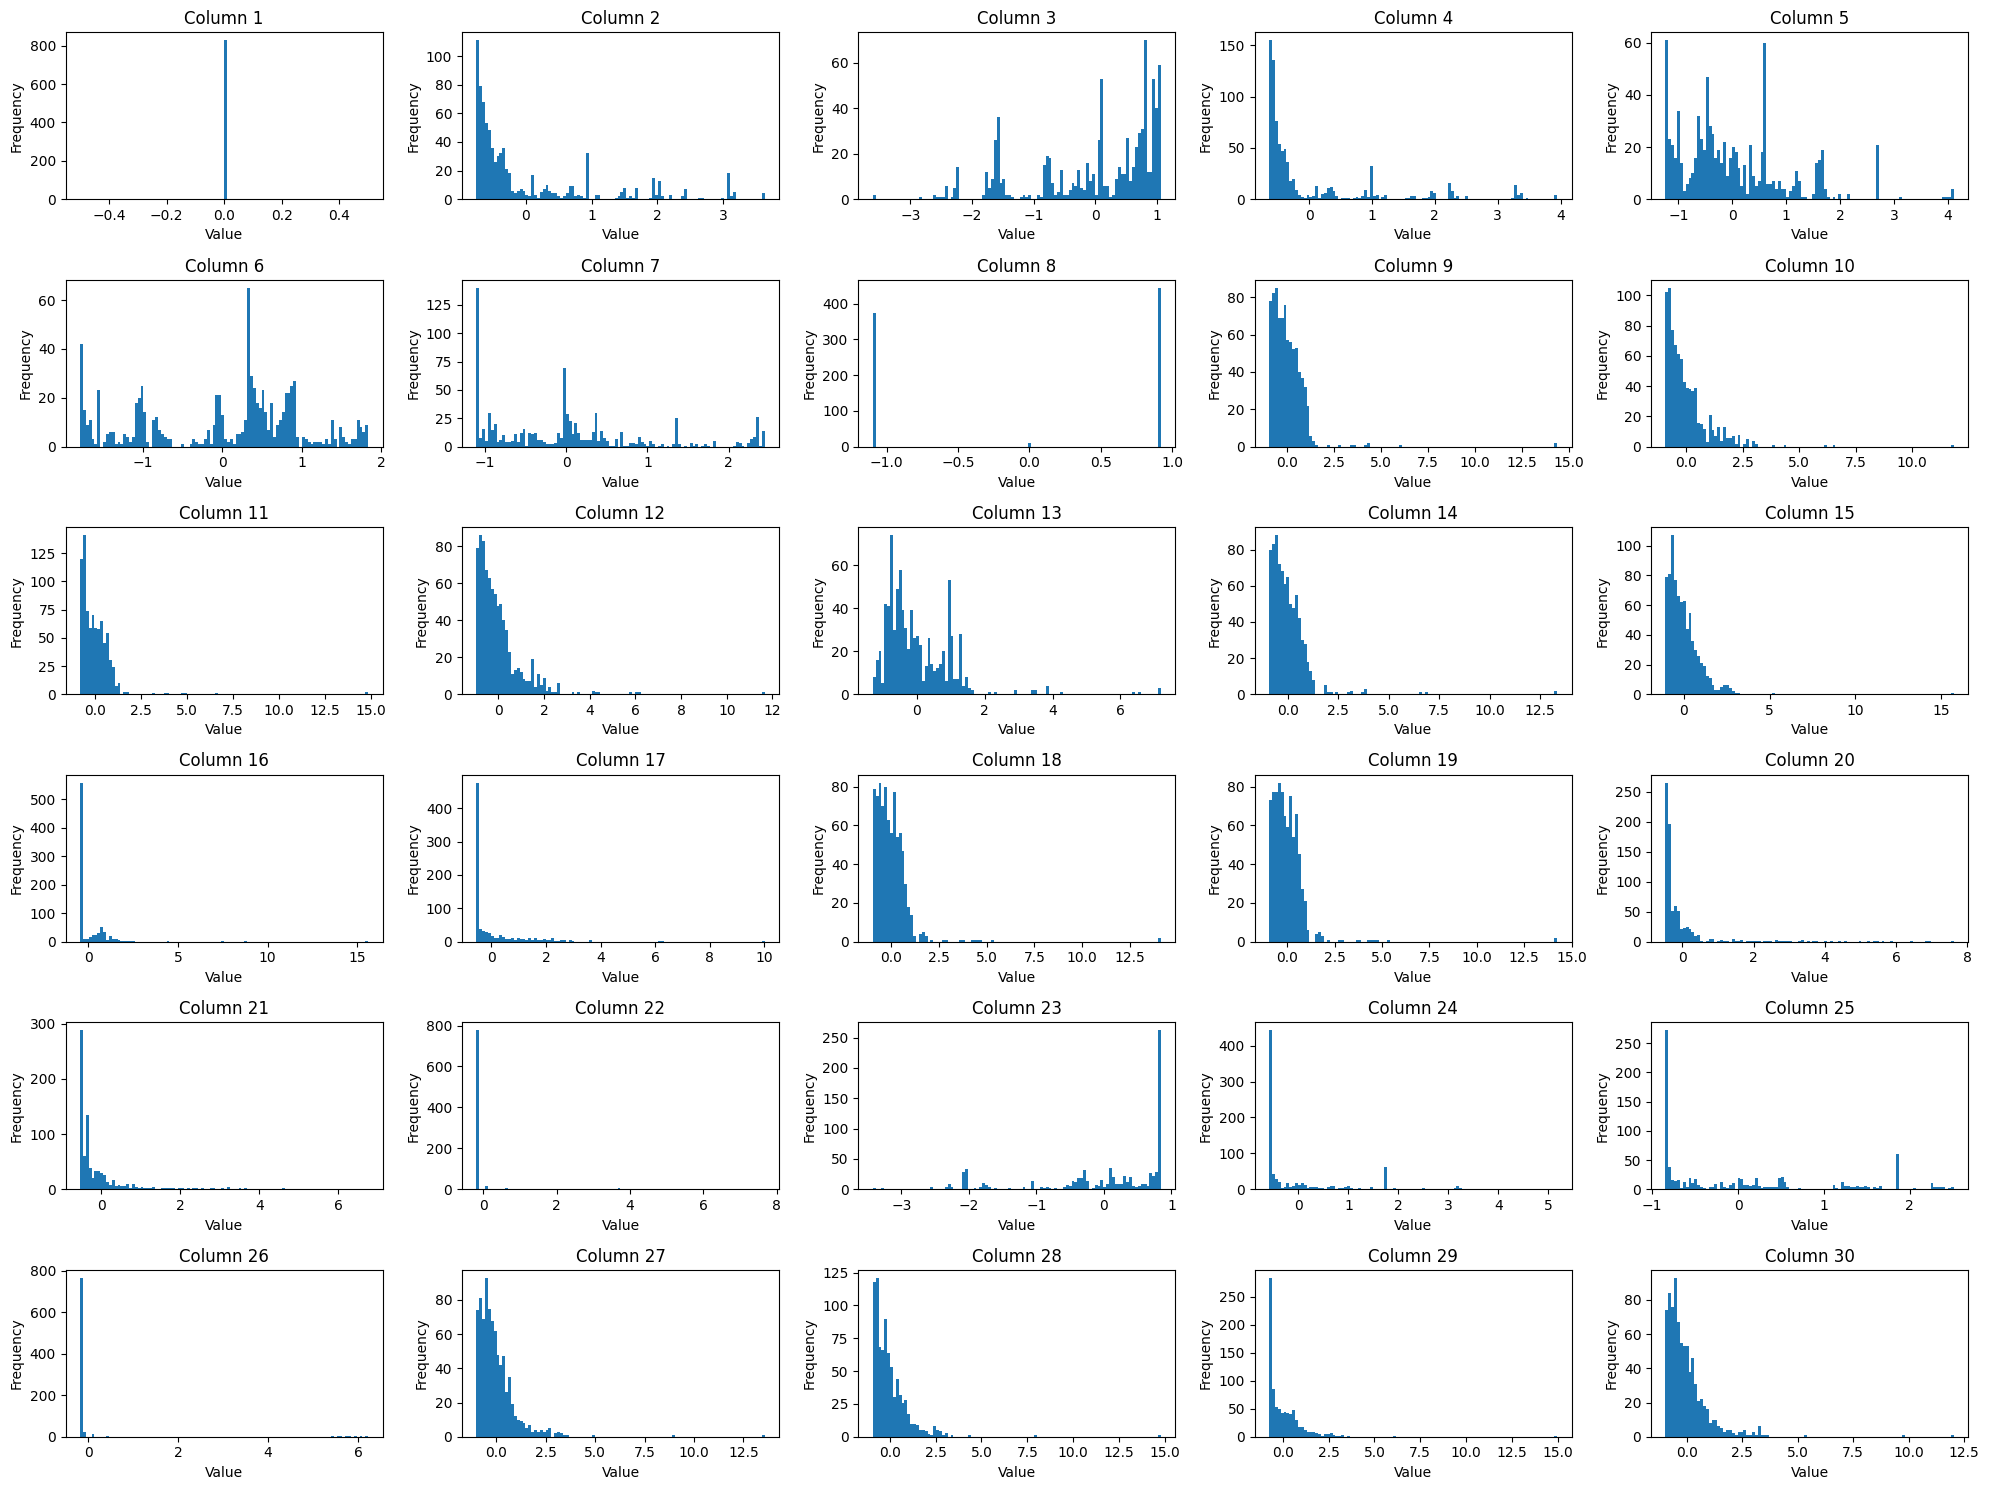

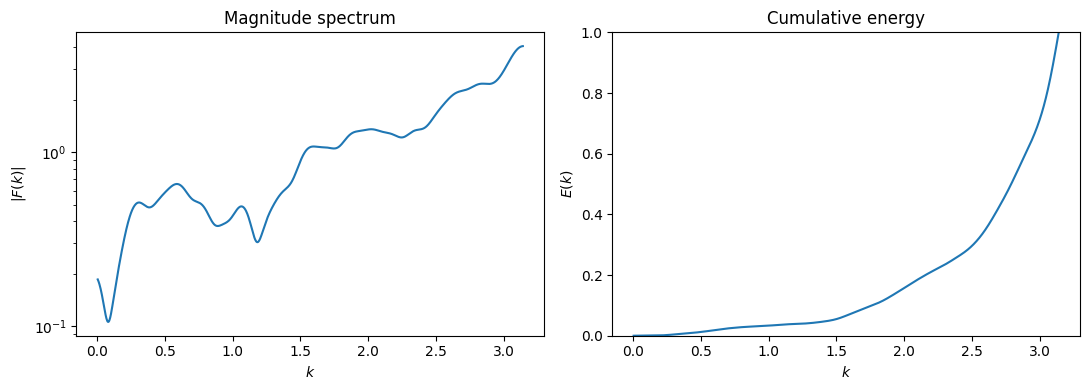

HF-energy (> 40% Nyq) = 96.01%
Spectral-decay exponent α ≈ -0.95
Relative Slopes Analysis:
         max_relative_slope  min_relative_slope  mean_relative_slope
feature                                                             
0                  0.000000            0.000000             0.000000
1                129.608756            0.000000             3.889704
2                151.386822            0.000000             3.270028
3                164.842571            0.000000             4.413126
4                141.978914            0.000000             2.942122
5                138.169820            0.000000             2.461743
6                145.757129            0.000000             2.764708
7                  1.695746            0.419547             0.997569
8                262.581556            0.000000             7.206196
9                252.338519            0.000000             6.751074
10               214.934252            0.000000             7.730844
11          

/tmp/ipykernel_2276772/1717818865.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(feature_data, labels=labels, showfliers=False)


Relative Slopes Statistics:
     feature  count      mean        std       min          max    median  \
0          0      0  0.000000   0.000000  0.000000     0.000000  0.000000   
1          1   5764  3.889704  10.757839  0.000000   129.608756  0.000000   
2          2   5764  3.270028  10.331123  0.000000   151.386822  0.000000   
3          3   4466  4.413126  11.412632  0.000000   164.842571  0.000000   
4          4   6842  2.942122   8.980083  0.000000   141.978914  0.000000   
5          5   6864  2.461743   8.021189  0.000000   138.169820  0.000000   
6          6   5544  2.764708   9.291462  0.000000   145.757129  0.000000   
7          7     22  0.997569   0.309210  0.419547     1.695746  1.004763   
8          8   8239  7.206196  21.559687  0.000000   262.581556  0.000000   
9          9   7777  6.751074  20.358199  0.000000   252.338519  0.000000   
10        10   6743  7.730844  22.075938  0.000000   214.934252  0.000000   
11        11   8459  6.474665  20.018014  0.0000

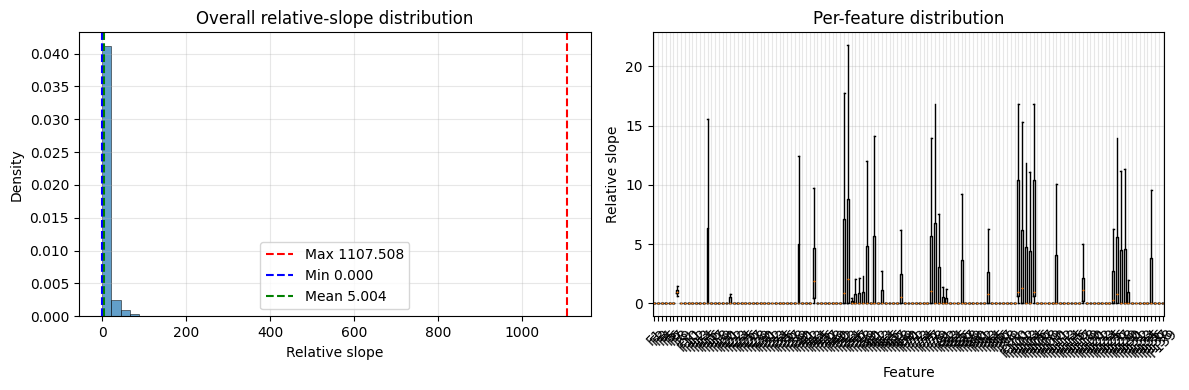

In [23]:
transform_list = [
    {
        'stretch_opt': 
            {
                'lambda_': 0.1
            }
    },
    {
        'norm':
            {
                'policy': 'standard'
            }
    }
]
N_trans, C_trans, y_trans, trans_results = transform_analysis(transform_list, N_data, C_data, y_data, is_regression)

In [ ]:
plot_relative_slope_distribution(trans_results, feature_idx=5, figsize=(16, 8))
plt.show()